# Détection des anomalies - les données
## Charger les configurations et les fonctions

In [1]:
%run helpers.py

## Créer notre ensemble de données

In [2]:
dataset = create_dataset()

# Choisissez le nombre d'échantillons d'entraînement à utiliser :
# Portion des échantillons d'entraînement qui sera des malwares (logiciels malveillants) :

Number of training samples to be used:
Please choose a number between 100 and 80819
No interactive input available - using 10000.

Portion of training samples to be attacks:
Please choose a number between 0 and 0.5 .
No interactive input available - using 0.1.



Your dataset has been created.


<div class="alert alert-info">
<h3>Important</h3>

La détection d'anomalies est une approche d'**apprentissage automatique non supervisée**.
Ainsi, le modèle **ne verra jamais les étiquettes de classe**, et ne pourra donc pas les comparer à ses propres "décisions" pour obtenir du feedback.    
    
Cependant, nous utiliserons ici les étiquettes de classe pour:   
- analyser et visualiser les données,   
- puis pour évaluer notre modèle plus en détail.
</div>

## On va explorer les données d'entraînement et visualiser 1000 échantillons

1) Nous examinons la distribution des différents types d'attaques dans nos données d'entraînement.

2) Nous utilisons TSNE (t-distributed stochastic neighbor embedding / encastrement stochastique de voisins) pour explorer une partie de nos données d'entraînement.   
Le TSNE-plot réduit nos 51 caractéristiques à 2 dimensions en essayant de représenter fidèlement les structures locales.

Your training set has the following composition:


,frequency
class,
normal,9000
neptune,246
ipsweep,169
satan,165
smurf,118
portsweep,114
nmap,59
warezclient,54
back,36


Plotting 1000 samples of the training data


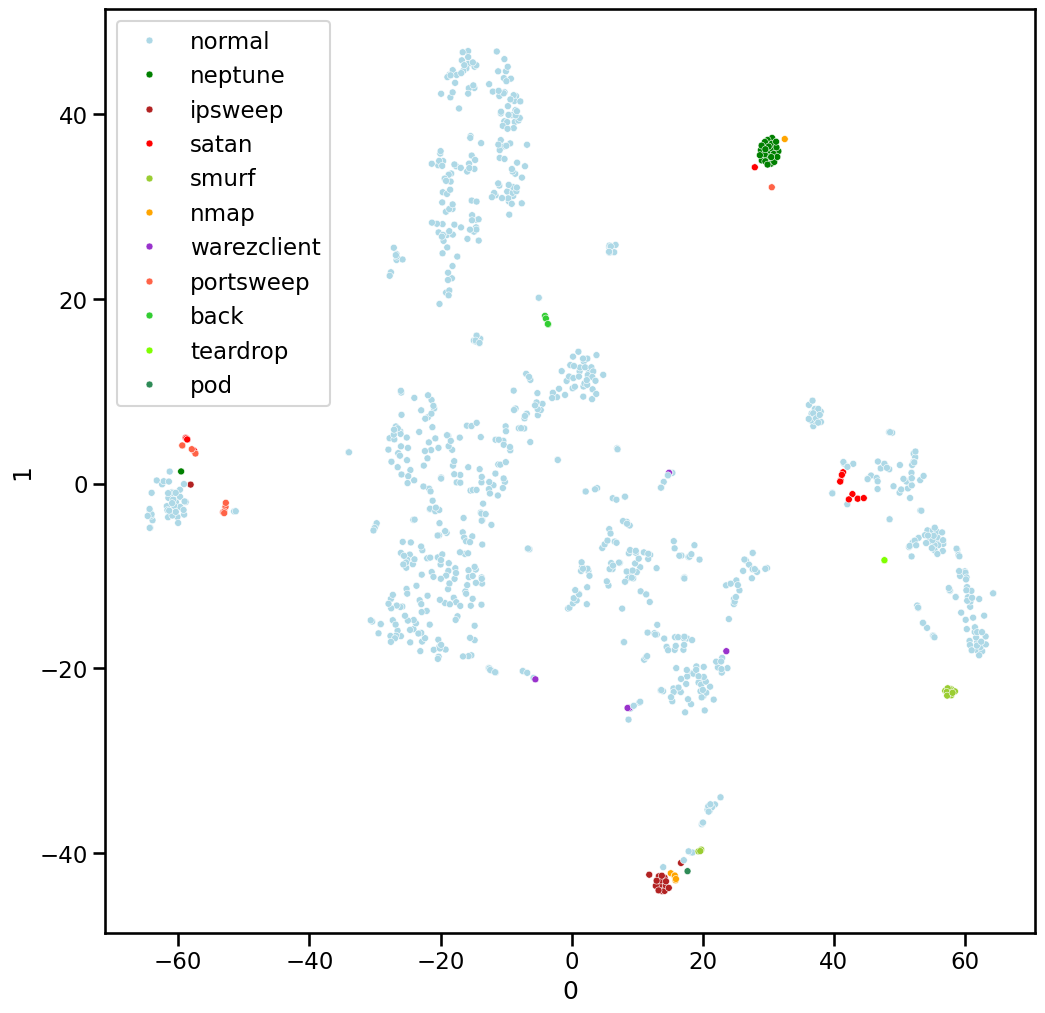

In [3]:
explore_and_visualise_training_data(dataset)

<div class="alert alert-success">
<h2>Questions - Partie 1</h2>
    
L'objectif des questions suivantes est de  
- d'estimer la performance de notre modèle et   
- d'anticiper les problèmes que le modèle pourrait rencontrer.
    
Remarque : ces questions n'ont de sens que pour les données d'entraînement qui ont été contaminées avec **malwares (_logiciels malveillants_)**
    
Qu'observez-vous à propos de

<ol>
<li> la <b>fréquence des différents types de malwares</b> dans notre ensemble de données ?
<li> la <b>distribution des types de malwares</b> dans le graphe TSNE ?
<li> la <b>distribution des échantillons normaux</b> dans le graphe TSNE ?
<li>Quels <b>types de malwares</b> devraient être <b>faciles à trouver</b>, et lesquels seraient <b>plus difficiles à détecter</b> ?
</ol>
</div>

Mes observations :

1. 
2. 
3. 
4.  

# Détection d'anomalies - le modèle
## Entraînement de notre modèle

La **contamination attendue (expected_contamination)** est la proportion d'anomalies (attaques) que nous attendons dans l'ensemble de test réel.  
**Attention**, cette valeur est indépendante de la *portion d'attaques* que nous avons choisi de placer dans les données d'entraînement.


**L'ACP (Analyse en Composantes Principales)** transforme nos données en essayant d'identifier les directions (= combinaisons de caractéristiques) dans les données dans lesquelles nos données varient le plus. Cela peut aider l'algorithme de la forêt d'isolation à isoler les anomalies plus rapidement, ou pas. On va voir.

In [4]:
model, dataset = build_anomaly_detector(
    dataset,
    expected_contamination=0.1,      # value between 0 and 0.5
    with_PCA = False)                # True / False

## Évaluer la performance

1) Nous examinons les scores attribués par la **fonction de décision** à nos différents échantillons. Les échantillons ayant des scores négatifs sont marqués comme des anomalies.

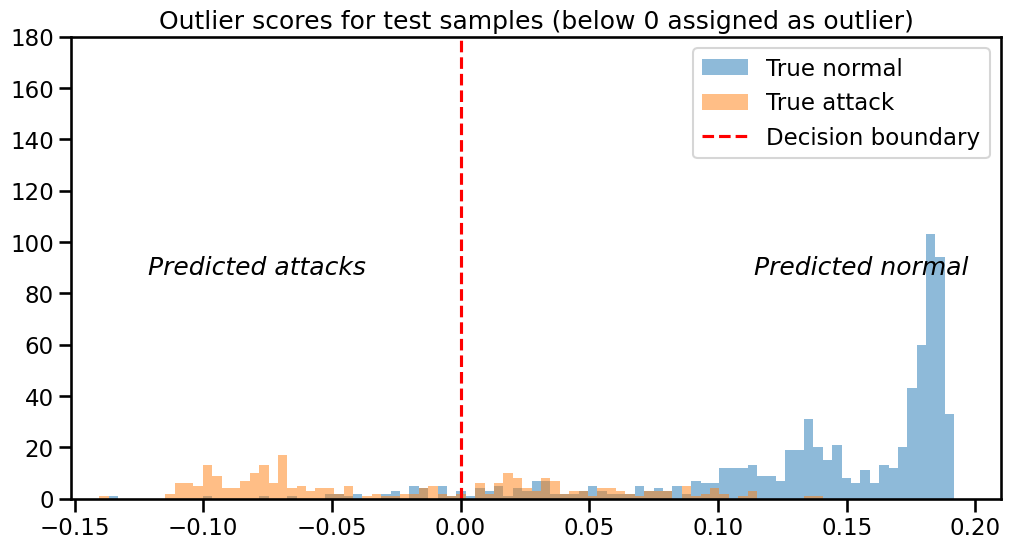

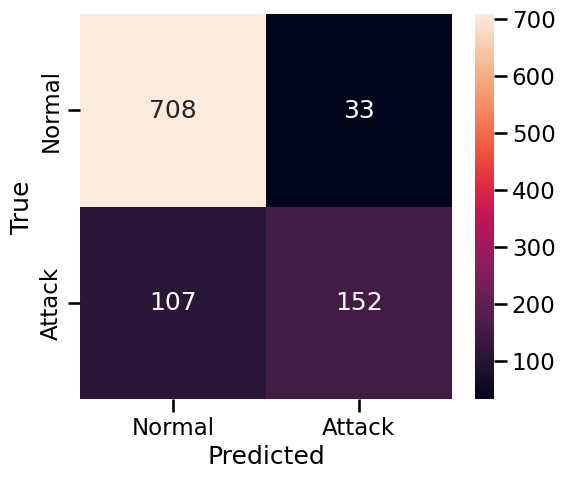

Summary report:
Attacks identified correctly (true positive): 152  of  259 ( 58.7 %)
Attacks missed (false negative): 107  of  259 ( 41.3 %)
False alarms (false positive): 33  of 741 ( 4.5 %)
Total number of misclassified samples: 140


In [5]:
evaluate_model(dataset, model)

<div class="alert alert-success">
<h2>Questions - Partie 2</h2>

<p>Jetons un coup d'œil aux les résultats ci-dessus. Regardez d'abord tout, puis essayez de répondre aux questions suivantes :</p>

<ol>
<li>  Dans le premier graphique, combien d'échantillons bleus se trouvent sur le côté gauche ?</li>
<li>  Dans le premier graphique, combien d'échantillons orange se trouvent sur le côté droit ?</li>
<li>  Laquelle de ces deux prédictions erronées est la pire pour nous ?</li>
</ol>

</div>

Mes observations:

1. 
2. 
3. 



## Regardons de plus près nos performances.

1) Nous examinons la performance de nos prédictions au niveau des types d'attaque individuels.

2) Nous localisons les échantillons mal classés dans notre ensemble de test. (**Les échantillons mal classés sont mis en évidence par des triangles, et leur couleur donne l'étiquette vraie**)

Detailed report:


,present,missed,pct_missed
attack_detail,,,
back,11,10,90.9
guess_passwd,1,0,0.0
ipsweep,40,33,82.5
neptune,68,0,0.0
nmap,16,12,75.0
normal,741,33,4.5
pod,2,2,100.0
portsweep,32,1,3.1
satan,40,17,42.5


Plotting 1000 samples of the test data




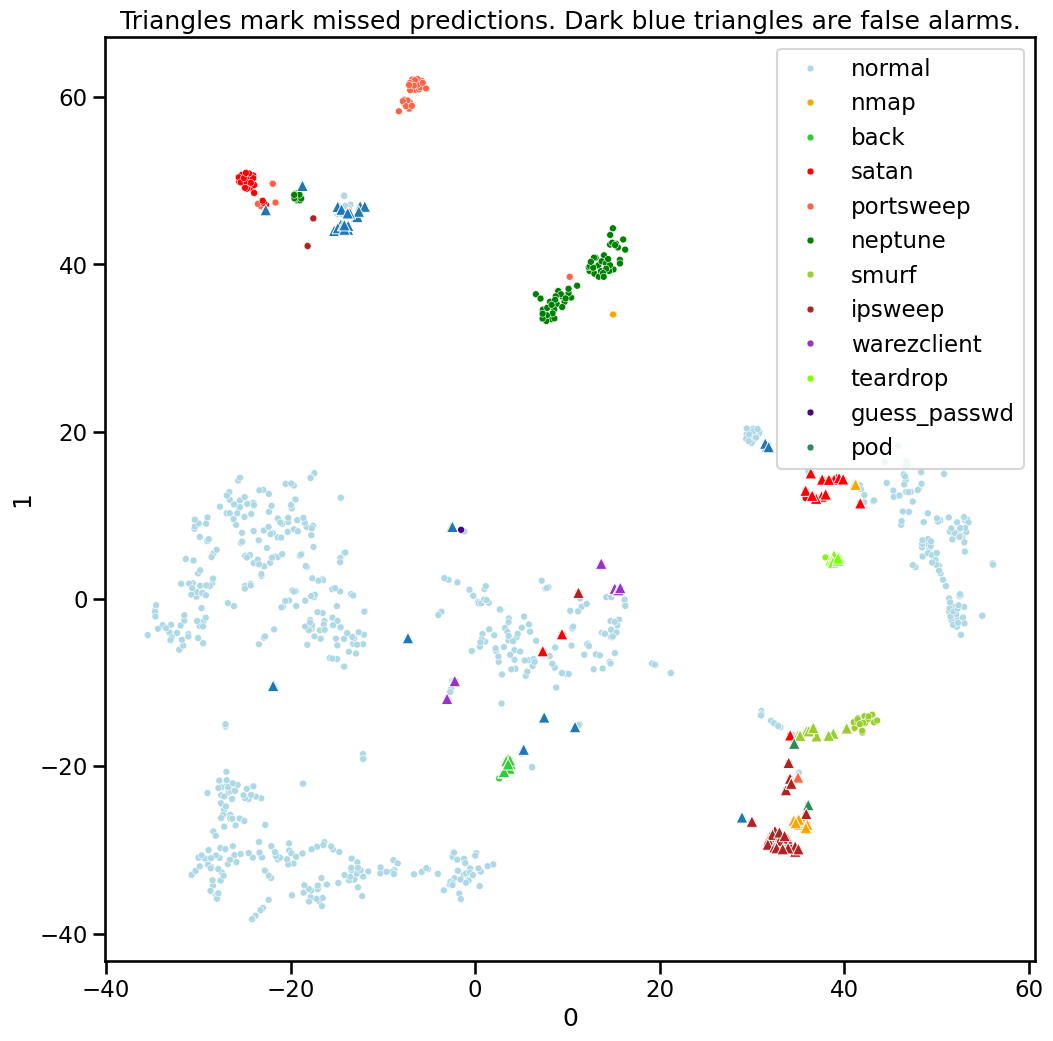

In [6]:
detailed_evaluation(dataset, model)

<div class="alert alert-success">
<h2>Questions - Partie 3</h2>

Comparons nos attentes établies dans la première partie avec les performances réelles.
    
<ol>
<li>  Pour quels types de logiciels malveillants notre modèle a-t-il donné de bons résultats, et pour lesquels a-t-il donné de mauvais résultats ?</li>
<li>  Cela correspond-il aux observations et aux attentes de la première partie ?</li>
</ol>   
<p>Les triangles bleu foncé indiquent les fausses alertes, c'est-à-dire un comportement normal qui a été prédit comme étant un logiciel malveillant. <br>
Les autres triangles indiquent des logiciels malveillants qui n'ont pas été détectés.</p>

<ol start="3">
<li>  Qu'observez-vous concernant l'emplacement des fausses alarmes ?</li>
<li>  Qu'observez-vous à propos de l'emplacement des logiciels malveillants non détectés ?</li>
<li>  Vos observations correspondent-elles aux observations et aux attentes formulées dans la première partie ?</li>
</ol>

</div>

Mes observations:

1. 
2. 
3. 
4. 
5. 


# Explorations supplémentaires


## Exploration 1


<div class="alert alert-success">

Faisons varier le paramètre `expected_contamination` qui est utilisé par le modèle pour prendre des décisions. <br> 
Il suffit d'exécuter les cellules de la section 2 "Détection d'anomalies - le modèle".

Qu'observez-vous concernant la distribution des scores aberrants et la position de la limite de décision ? <br>
    
</div>

Mes observations:
  
  

## Exploration 2


<div class="alert alert-success">

Vous devez réexécuter le cahier entier ici.

1. Variez la taille de vos données d'entraînement.<br>
2. Variez la proportion d'attaques dans vos données d'entraînement.<br>
3. En particulier, voyons comment le modèle se comporte lorsque nous **utilisons uniquement des données d'entraînement totalement propres, sans aucune anomalie**.<br>
</div>

Mes observations:
  
  

Mes observations:


## Exploration 3


<div class="alert alert-success">
    
Voyons si l'utilisation de l'ACP (Analyse des composantes principales) avant l'entraînement de notre modèle est utile. <br>
Vous avez seulement besoin d'exécuter les cellules de la section 2 "Détection d'anomalies - le modèle".     <br>
Définissez `with_PCA = True` dans la commande `build_anomaly_detector`. <br>
</div>

Mes observations:
  
  

Mes observations:

